# P2: Ley de Pzif
Veremos si un idioma artificial creado aleatoreamente cumple con la ley de Pzif, y veremos como se comporta una lengua con pocos recursos digitales.

In [1]:
# Importamos las librerías necesarias
import pdfplumber
import re
import numpy as np
import pandas as pd
from collections import Counter
from scipy.optimize import minimize
import matplotlib.pyplot as plt

## Procesamiento de texto

In [2]:
def limpia_pdf(pdf_path):
    texto = ""
    with pdfplumber.open(pdf_path) as pdf:
        for pagina in pdf.pages:
            texto += pagina.extract_text() + "\n"
    texto = texto.lower()
    texto = re.sub(r"\d+", "", texto)
    texto = re.sub(r"[^\w\s']", " ", texto)
    return texto.split()

def contar_palabras(texto):
    conteo = Counter(texto)
    return conteo

def crear_dataframe(conteo):
    df = pd.DataFrame(conteo.items(), columns = ["Palabras","Frecuencia"])
    df = df.sort_values("Frecuencia", ascending = False,).copy()
    df["Rango"] = range(1,len(df)+1)
    return df

## Generando un idioma artificial.

In [3]:
# Definimos el alfabeto y la longitud de las palabras (con un espacio)
alfabeto = "abcdefghijklmnñopqrstuvwxyz "
letras_sueltas = np.random.choice(list(alfabeto), size=5000000, replace=True)
chorizo_de_letras = "".join(letras_sueltas)
texto_artificial = chorizo_de_letras.split()

In [4]:
# Longitud de nuestro texto artificial, 
len(texto_artificial)

171911

## procesamos el texto artificial y analizamos su distribución de palabras.

In [18]:
conteo_artificial = contar_palabras(texto_artificial)
df = crear_dataframe(conteo_artificial)
df.head(15)

,Palabras,Frecuencia,Rango
480,w,258,1
574,o,253,2
665,a,249,3
2081,c,245,4
809,j,244,5
488,t,244,6
4,r,243,7
1025,p,237,8
460,k,235,9
39,x,235,10


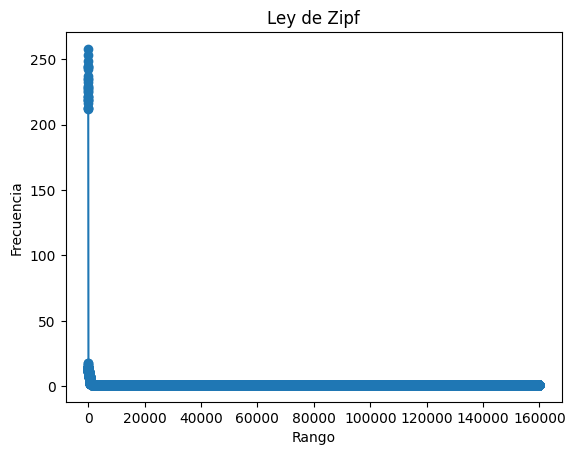

In [6]:
plt.plot(df["Rango"],df["Frecuencia"],marker = "o")
plt.title("Ley de Zipf")
plt.xlabel("Rango")
plt.ylabel("Frecuencia")
plt.show()

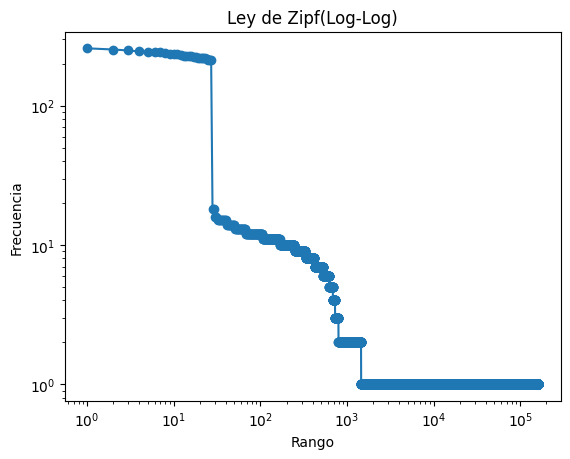

In [7]:
plt.loglog(df["Rango"], df["Frecuencia"], marker="o")
plt.title("Ley de Zipf(Log-Log)")
plt.xlabel("Rango")
plt.ylabel("Frecuencia")
plt.show()

## Estimando el parametro alfa (usando el notebook de clase)

In [8]:
ranks = np.array(df["Rango"])
frequencies = np.array(df["Frecuencia"])

In [9]:
def zipf_minimization_objective(
    alpha: np.float64, word_ranks: np.ndarray, word_frequencies: np.ndarray
) -> np.float64:
    predicted_log_freq = np.log(word_frequencies[0]) -alpha * np.log(word_ranks)
    return np.sum((np.log(word_frequencies) - predicted_log_freq) ** 2)

In [10]:
initial_alpha_guess = 1.0

optimization_result = minimize(
    zipf_minimization_objective,
    initial_alpha_guess,
    args=(ranks, frequencies)
)

estimated_alpha = optimization_result.x[0]

mean_squared_error = zipf_minimization_objective(
    estimated_alpha, ranks, frequencies
)

print(f"Estimated alpha: {estimated_alpha:.4f}")
print(f"Mean Squared Error: {mean_squared_error:.4f}")

Estimated alpha: 0.5009
Mean Squared Error: 33388.3949


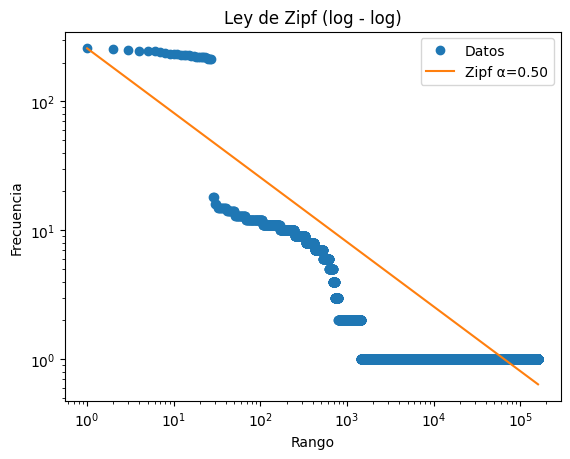

In [11]:
plt.loglog(ranks, frequencies, "o", label="Datos")

zipf_fit = frequencies[0] * ranks**(-estimated_alpha)

plt.loglog(ranks, zipf_fit, label=f"Zipf α={estimated_alpha:.2f}")

plt.title("Ley de Zipf (log - log)")
plt.xlabel("Rango")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

## ¿Se aproxima a la ley de Zipf?
No, podemos ver que la curva no se ajusta a los datos (log-log) y que el parametro alfa no está cerca de ser 1 como pasa en los lenguajes naturales, asi que nuestro texto aleatorio no sigue la ley de Zipf

## Analizando un corpus con pocos recursos digitales
Analizaremos una biblia de Tzotzil de los altos de chiapas, exáctamente del Tzotzil de Zinacantán.

In [12]:
biblia_tzotzil = limpia_pdf("biblia_tzotzil.pdf")
conteo_tzo = contar_palabras(biblia_tzotzil)
df_tzo = crear_dataframe(conteo_tzo)

In [13]:
# DataFrame ordenado 
df_tzo.head(20)

,Palabras,Frecuencia,Rango
0,ti,39490,1
133,ta,24887,2
222,jech,8456,3
107,laj,6574,4
119,jaꞌ,4937,5
3,yuꞌun,4445,6
281,mu,2503,7
218,tey,2302,8
328,diose,2196,9
256,oy,2154,10


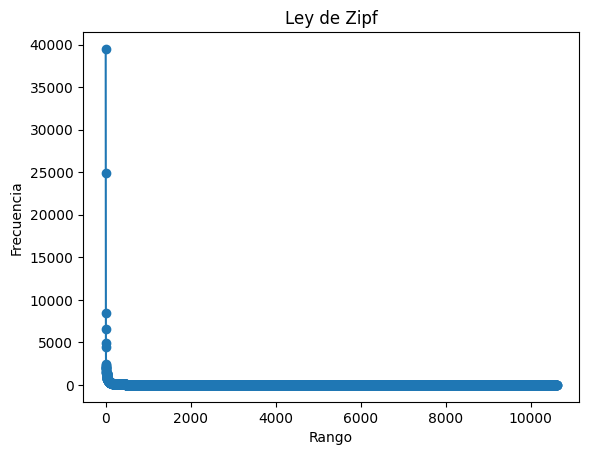

In [14]:
plt.plot(df_tzo["Rango"],df_tzo["Frecuencia"],marker = "o")
plt.title("Ley de Zipf")
plt.xlabel("Rango")
plt.ylabel("Frecuencia")
plt.show()

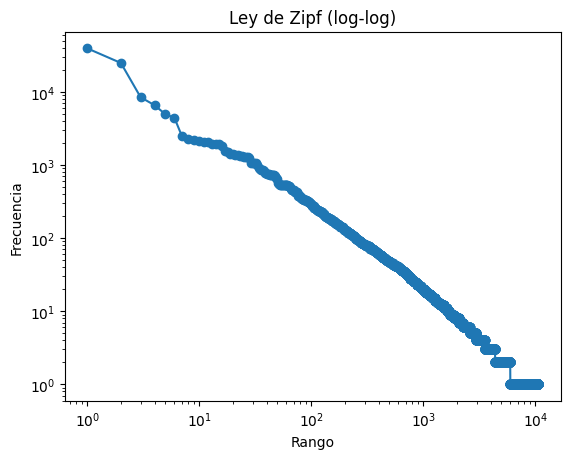

In [15]:
plt.loglog(df_tzo["Rango"],df_tzo["Frecuencia"],marker = "o")
plt.title("Ley de Zipf (log-log)")
plt.xlabel("Rango")
plt.ylabel("Frecuencia")
plt.show()

In [16]:
ranks = np.array(df_tzo["Rango"])
frequencies = np.array(df_tzo["Frecuencia"])
initial_alpha_guess = 1.0

optimization_result = minimize(
    zipf_minimization_objective,
    initial_alpha_guess,
    args=(ranks, frequencies)
)

estimated_alpha = optimization_result.x[0]

mean_squared_error = zipf_minimization_objective(
    estimated_alpha, ranks, frequencies
)

print(f"Estimated alpha: {estimated_alpha:.4f}")
print(f"Mean Squared Error: {mean_squared_error:.4f}")

Estimated alpha: 1.1547
Mean Squared Error: 681.0885


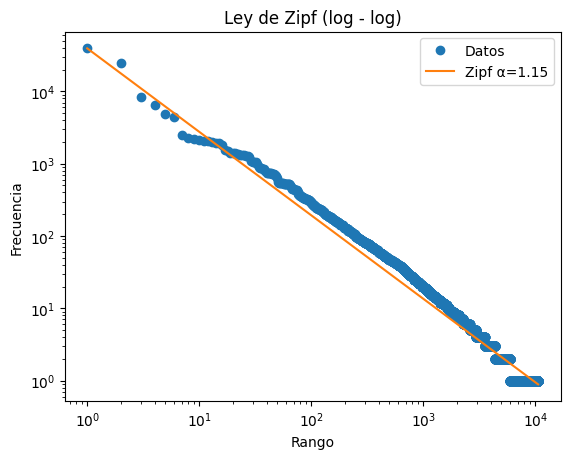

In [17]:
plt.loglog(ranks, frequencies, "o", label="Datos")

zipf_fit = frequencies[0] * ranks**(-estimated_alpha)

plt.loglog(ranks, zipf_fit, label=f"Zipf α={estimated_alpha:.2f}")

plt.title("Ley de Zipf (log - log)")
plt.xlabel("Rango")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

### ¿Se aproxima a la ley de Zipf?
Si, notemos que la gŕafica logaritmica se acerca mucho a la recta generada por el alfa calculada anteriormente, pro que lo podemos concluir que aunque el corpus del Tzotzil sea uno muy pequeño, al ser el Tzotzil una lengua natural claramente sigue la ley de Zipf.

In [ ]:
## 